## Module 4:

## Team Members:
Luke Friscia and Hayden Rue

## Project Title:
Assessment of MMP9 Expression and Its Association with Survival and Disease Characteristics in Melanoma

## Project Goal:
This project seeks to evaluate whether MMP9 expression is associated with metastatic progression, tumor stage, and survival outcomes in melanoma patients, and assess its predictive value using machine learning models.

## Disease Background:

Cancer hallmark focus: Activating invasion and metastasis

Overview of hallmark: This hallmark references the capacity for cancer cells to detach from the primary tumor, invade surrounding tissues, and spread to distant sites in the body. It's a multistep biological process that involves local invasion, degradation of the surrounding ECM, entry into vessels, survival during circulation, exit into new tissues, and growth in a new environment. The hallmark is a major driver of cancer lethality because metastatic disease is harder to treat. 

Genes associated with hallmark to be studied: For this analysis, we picked MMP9 as the main gene of interest in SKCM due to its role in melanoma invasion and metastasis. MMP9 encodes an enzyme that degrades components of the ECM, particularly type IV collagen in basement membranes, which directly promotes tumor cell invasion into surrounding tissues and entry into circulation.

In melanoma, elevated MMP9 expression has been associated with increased tumor aggressiveness and metastatic potential. A supporting study for this selection is:

Wu et al., 2025 — Comprehensive investigation of matrix metalloproteinases in skin cutaneous melanoma: diagnostic, prognostic, and therapeutic insights

The authors of the study found that several MMP family members are  upregulated in SKCM compared to normal tissue. Importantly, elevated MMP expression was associated with tumor aggressiveness and poorer clinical outcomes. The study highlights that MMPs contribute to melanoma progression by promoting extracellular matrix (ECM) degradation, which facilitates tumor cell invasion and metastasis. Among these, MMP9 is emphasized as a key regulator of tumor microenvironment remodeling and metastatic potential.

Cancer Type: Skin Cutaneous Melanoma (SKCM)

Prevalence & incidence: Skin cutaneous melanoma is one of the most aggressive forms of skin cancer, though less common than other skin cancers. In the U.S., there are over 90,000–100,000 new cases diagnosed annually, with approximately 7,000–8,000 deaths per year. While early-stage melanoma has a high survival rate, advanced or metastatic melanoma significantly reduces survival. Because of improved detection and therapies, many patients now live longer with melanoma compared to previous decades.

Risk factors (genetic, lifestyle) & Societal determinants: Key risk factors include excessive ultraviolet (UV) radiation exposure (from sunlight or tanning beds), fair skin, genetic predisposition like mutations affecting melanocyte regulation, and a large number of sunburns in the past. Societal determinants might include access to dermatologic care, awareness and screening practices, socioeconomic status, etc.
    
 
Standard of care treatments (& reimbursement): Treatment for SKCM usually depends on disease stage. Early-stage melanoma is typically treated with surgical excision. Advanced melanoma may require immunotherapy (such as checkpoint inhibitors targeting PD-1/PD-L1 or CTLA4), targeted therapy for specific mutations, radiation, or chemotherapy in select cases. Immunotherapies have become a much more popular area treatment and are widely used in high-income countries, though access and reimbursement may vary globally.
    

Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): Skin cutaneous melanoma originates in melanocytes in the epidermis, the pigment-producing cells of the skin that are regularly exposed to UV radiation. This in turn increases the risk of DNA damage and mutations. At the cellular level, accumulated mutations lead to uncontrolled growth and proliferation of melanocytes, while the immune systeme tries to recognize and eliminate the abnormal cells. However, melanoma cells are able to escape immune destruction by using functions of immune checkpoint pathways. On a molecular level, many melanoma tumors overexpress PD-L1, which binds to PD-1 receptors on T cells and reduces their ability to kill cancer cells. In addition, alterations in pathways like JAK/STAT signaling and decreased antigen presentation through MHC downregulation further help tumors evade immune detection. As with other cancers, melanoma can also be described as “hot” tumors, which have high immune cell infiltration and tend to respond better to immunotherapy, or “cold” tumors, which have lower immune activity and are less responsive to treatment.



## Dataset Background

This study uses data collected from The Cancer Genome Atlas (TCGA), a widespread cancer genomics initiative that characterizes many features across multiple types of cancer. Specifically, we have used the RNA-seq dataset reprocessed by Rahman et al., which standardizes gene expression measurements across tumors.

From the full TCGA dataset (~9,264 tumor samples across 24 cancer types), a subset of ~1,802 tumors was selected, with approximately 50–100 samples per cancer type.

For this project analysis, the dataset was further filtered to include only Skin Cutaneous Melanoma (SKCM) patients. Lymph node status, survival outcomes, and age at diagnosis are also relevant columns in the dataset that will be used for this project.

Data was obtained from tumor samples via surgical biopsy. Gene expression was measured using RNA sequencing. Clinical data, including tumor stage, lymph node involvement, and survival outcomes, were derived from patient medical records and classified using the TNM staging system. Survival time was recorded in days from diagnosis to last follow-up or death.

## Data Analysis: 

### Methods

The machine learning technique we are using is: unsupervised learning, specifically Principal Component Analysis (PCA) combined with K-Means clustering. This approach is appropriate because the goal is to explore patterns in gene expression data from SKCM samples. We first reduce the dimensionality of the dataset by selecting an appropriate number of specific genes incluiding MMP9. PCA is then applied to transform this high-dimensional gene expression data into a lower-dimensional space (two principal components) that captures the greatest variance in the dataset. This in turn allows us to visualize relationships between samples and identification of potential structure in the data.

PCA finds new orthogonal axes (principal components) that maximize variance. The first principal component captures the greatest amount of variance, followed by PC2. The model is "effective" if these components account for a significant proportion of the total variance and show separation when plotted.

After dimensionality reduction, K-Means clustering is applied to group samples by similarity in gene expression. K-Means partitions the data into a predefined number of clusters by minimizing the sum of squared distances between samples and assigned cluster centroids (within a cluster). The algorithm updates cluster assignments and centroids until convergence, (assinged clusters) no longer change significantly.

The "good enough" determination is made when clustering stabilizes and produces distinct groupings in PCA space. These clusters can then be interpreted by comparing them to clinical variables like those which we have generated from the dataset (MMP9 expression, metastasis status, tumor stage, survival outcomes). As a result, we can assess whether gene expression patterns correspond to meaningful clinical differences.

Furthermore, the central supervised learning model we used is a Random Forest classifier. This model builds multiple decision trees and combines their predictions to improve accuracy and robustness. It's well-suited for high-dimensional gene expression data and can capture nonlinear relationships between genes and clinical outcomes. It also provides feature importance scores, allowing identification of biologically relevant genes such as MMP9.

Secondarily, we used a regression model to verify the results from the random forrest classifier. A regression model is a useful complement as it provides a continuous, interpretable relationship between gene expression and survival outcomes. While the classifier can capture complex, non-linear patterns and classify patients, a regression approach helps validate whether those patterns hold as consistent trends across expression levels. Using both methods together strengthens confidence in the findings by combining prediction with statistical information.


### Analysis


Load and process data from Training Sets:

In [15]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv('/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0)
metadata_df = pd.read_csv('/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0)

# Match IDs
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

common_ids = set(data_short).intersection(set(meta_short))

data = data[[data_map[i] for i in common_ids]]
metadata_df = metadata_df.loc[[meta_map[i] for i in common_ids]]

# Filter SKCM
SKCM_metadata = metadata_df[metadata_df['cancer_type'] == 'SKCM']
SKCM_data = data[SKCM_metadata.index]

# Select genes
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(45).index
genes = list(set(top_genes).union({'MMP9'}))

SKCM_gene_data = SKCM_data.loc[genes]

# Merge
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)

SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9','ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage','OS','OS.time'
])

### Clinical Association Plots
MMP9 expression was analyzed using multiple clinical association plots that highlight different dependent variables.

First, MMP9 expression was plotted vs metastasis status in a boxplot across the different status levels collected from TCGA.

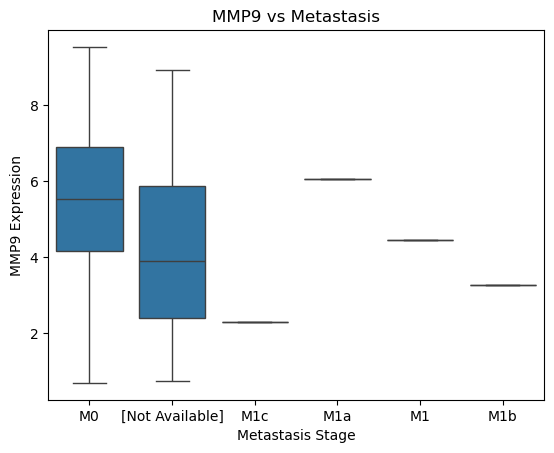

In [16]:
#clinical association plots

sns.boxplot(data=SKCM_merged,
            x='ajcc_metastasis_pathologic_pm',
            y='MMP9')
plt.title("MMP9 vs Metastasis")
plt.xlabel("Metastasis Stage")
plt.ylabel("MMP9 Expression")
plt.show()

From this plot, there is no clear trend between MMP9 and metastasis stage. This is due to small and uneven sample sizes among the groups and lack of metastasis data for the [not avaliable] group

There is some evidence that MMP9 might decrease in more advanced sub-stages (M1c or M1b), however this is not conclusive trustworthy given the data.


Next, MMP9 expression was plotted against the different tumor stages as collected from TCGA.

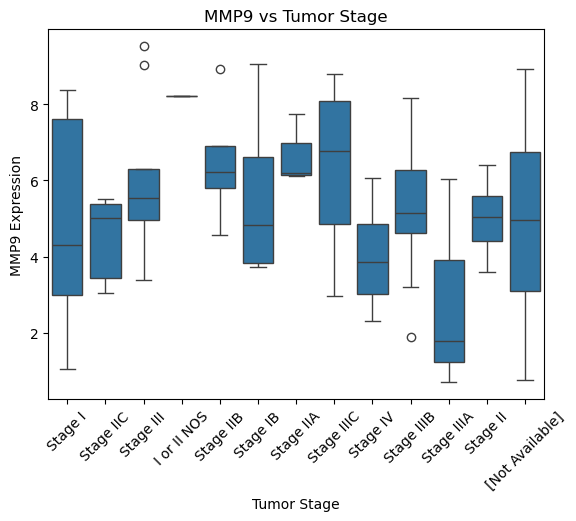

In [17]:
# Clinical association plots

# Compare MMP9 across tumor stages
sns.boxplot(data=SKCM_merged,
            x='ajcc_pathologic_tumor_stage',
            y='MMP9')
plt.title("MMP9 vs Tumor Stage")
plt.xlabel("Tumor Stage")
plt.ylabel("MMP9 Expression")
plt.xticks(rotation=45)
plt.show()

From this plot, no clear relationship between tumor stage and MMP9 expression can be seen.

MMP9 expression was then plotted against survival status (alive vs deceased)

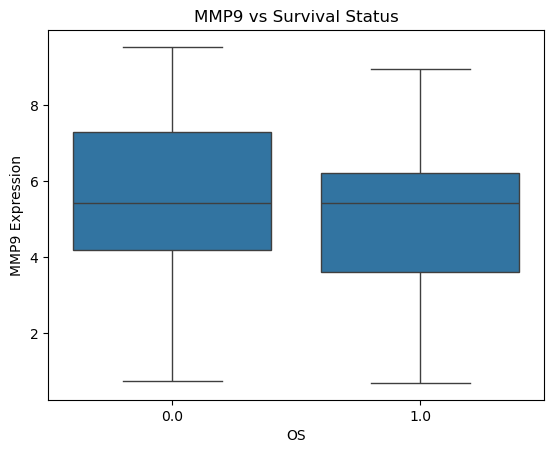

In [18]:
# Clinical association plots

# Compare MMP9 between patients who are alive vs deceased
sns.boxplot(data=SKCM_merged,
            x='OS',
            y='MMP9')
plt.title("MMP9 vs Survival Status")
plt.ylabel("MMP9 Expression")
plt.show()

This clinical association plot shows no strong relationship between alive vs deceased patients and MMP9 expression, however, due to the low variation in the two samples and small sample size, further investigation may reveal trends.

The final clinical associaton plot plotted MMP9 expression vs patient survival time from diagnosis.

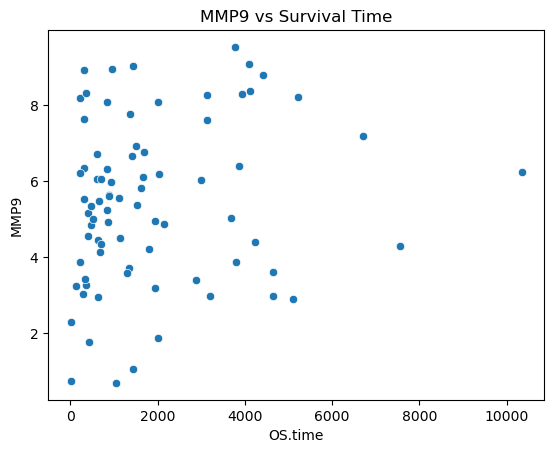

In [19]:
# Clinical association plots

# Look at relationship between MMP9 and survival time
sns.scatterplot(data=SKCM_merged,
                x='OS.time',
                y='MMP9')
plt.title("MMP9 vs Survival Time")
plt.show()

Similar to survival outcomes, survival time does not show a strong correlation with MMP9 expression, however we will further evaluate this claim using superivsed and unsupervized ML models.

PCA was used to analyze the overall structure in the gene expression data. ~150 genes were reduced to 2 dimensions and were colored by MMP9 expression to observe global expression patterns

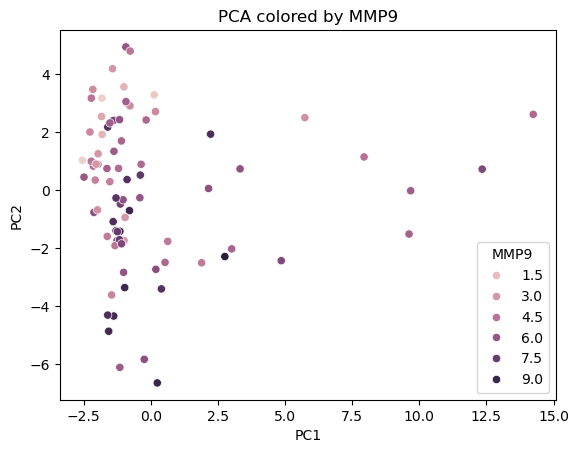

In [20]:
X = SKCM_gene_data.T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, columns=['PC1','PC2'], index=X.index)

pca_df['MMP9'] = SKCM_gene_data.loc['MMP9']

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='MMP9')
plt.title("PCA colored by MMP9")
plt.show()

Coloring by MMP9 shows a gradient rather than discrete separation in the PCA, where higher MMP9 expression (darker colors) appears more frequent in certain regions. These regions include some of the more negative PC2 values, parts of the left cluster cloud, and a few mid to far-right points.

Following PCA analysis, K-Means clustering was then implemented to analyze subgroups of patients based on gene expression similarity. The plot is colored by the different clusters.

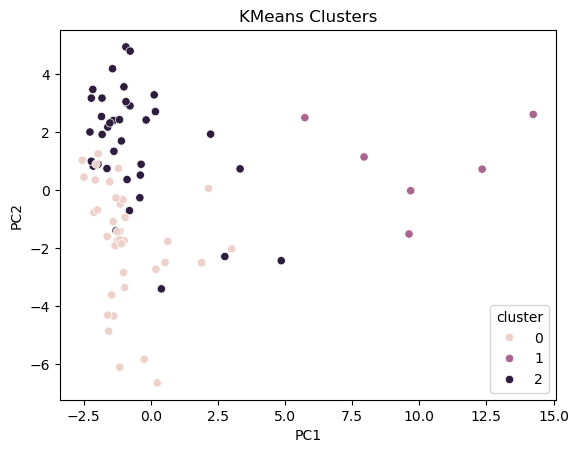

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
pca_df['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster')
plt.title("KMeans Clusters")
plt.show()

Based on the clustering, most samples are tightly grouped on the left side (PC1 ≈ -2 to 1), forming two overlapping clusters (0 and 2), while cluster 1 is more spread out toward higher PC1 values (right side). The right-shifted cluster likely represents a distinct subgroup of patients with different underlying gene expression profiles.

The fact that cluster 1 separates along PC1 suggests that the primary axis of variation (PC1) captures a biologically meaningful difference. If the RF classifier find survival differences, this cluster could correspond to a different risk group (better or worse survival). That being said, MMP9 expression alone likely won’t fully explain survival outcomes as based on the analysis it seems a contributing biomarker instead of a sole driver.

### Supervised Learning Model 

After identifying patterns in gene expression using PCA and K-Means clustering, we then evaluated whether these molecular features can predict clinical outcomes using a random forrest classification supervised learning model.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

X = SKCM_gene_data.T.loc[SKCM_merged.index]
y = SKCM_merged['OS'].astype(int)

# Add PCA features
X['PC1'] = pca_df.loc[X.index, 'PC1']
X['PC2'] = pca_df.loc[X.index, 'PC2']

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

# Probabilities
y_prob_val = model.predict_proba(X_val)[:,1]

### Random Forest Performance

To evaluate how well the model predicts survival outcomes, we used:
- Accuracy: proportion of correct predictions vs incorret predictions
- ROC-AUC: ability of the model to distinguish alive vs deceased patients

In [49]:
# Metrics
print("Classification Performance")
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_val))

Classification Performance
Training Accuracy: 1.0
Validation Accuracy: 0.3125
Validation ROC-AUC: 0.2698412698412698


### ROC curve
The ROC curve shows the tradeoff between true positive rate and false positive rate.
The closer the curve is to the top-left corner, the better the model performs.

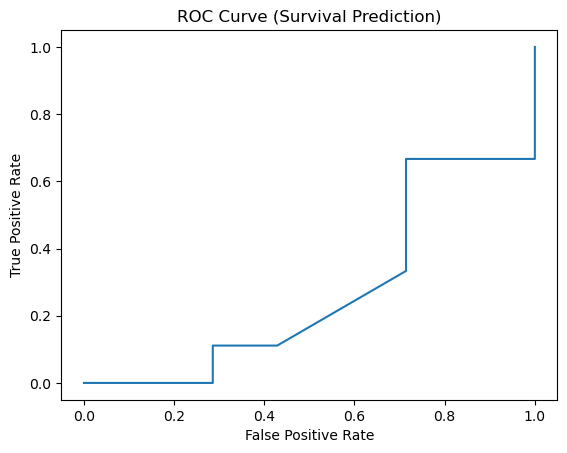

Validation ROC-AUC: 0.2698412698412698


In [50]:
fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Survival Prediction)")
plt.show()
auc = roc_auc_score(y_val, y_prob)
print("Validation ROC-AUC:", auc)

### Model Error

In-sample vs Out-of-sample error was then calculated to determine whether the model is overfitting.

In [51]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

print("Train Accuracy:", train_acc)
print("Train Error:", 1 - train_acc)

print("Validation Accuracy:", val_acc)
print("Validation Error:", 1 - val_acc)

Train Accuracy: 1.0
Train Error: 0.0
Validation Accuracy: 0.3125
Validation Error: 0.6875


Feature importance identifies which genes contribute most to survival prediction.
We specifically examined whether MMP9 is an important predictor.

In [52]:
importances = pd.Series(model.feature_importances_, index=X.columns)

print("Top Features:")
print(importances.sort_values(ascending=False).head(10))

print("MMP9 Importance:")
print(importances['MMP9'])

Top Features:
PI3        0.046699
MMP9       0.043304
NGFR       0.042624
FABP7      0.041957
GDF15      0.035501
ANGPTL7    0.035015
S100A8     0.034945
FDCSP      0.034410
PAEP       0.032571
MPZ        0.026411
dtype: float64
MMP9 Importance:
0.04330368037219036


### Regression Model (Survival Time Prediction)

In addition to classification, we used a regression model to predict survival time.
This allows us to evaluate whether gene expression,including MMP9,
relates to how long patients survive, not just overall survival status.

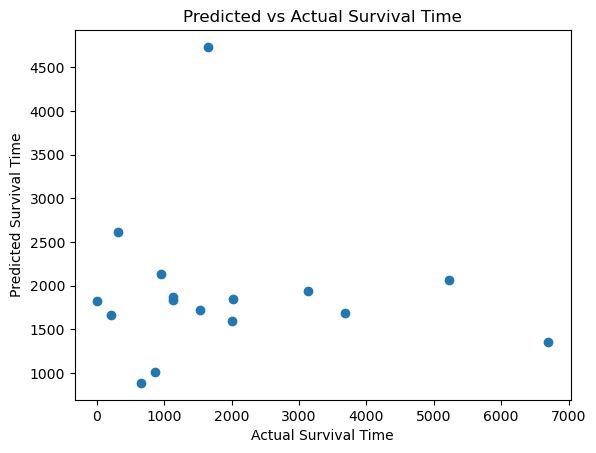

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Target = survival time
y_time = SKCM_merged['OS.time']

# Align
X_reg = X.loc[y_time.index]

# Split
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_reg, y_time, test_size=0.2, random_state=42
)

# Train
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_r, y_train_r)

# Predict
y_pred_train_r = reg_model.predict(X_train_r)
y_pred_val_r = reg_model.predict(X_val_r)

#Plot
plt.scatter(y_val_r, y_pred_val_r)
plt.xlabel("Actual Survival Time")
plt.ylabel("Predicted Survival Time")
plt.title("Predicted vs Actual Survival Time")
plt.show()

Model performance is evaluated using:
- MSE (Mean Squared Error): prediction error
- R²: proportion of variance explained by the model

In [74]:
print("\n--- REGRESSION PERFORMANCE ---")

print("Train MSE:", mean_squared_error(y_train_r, y_pred_train_r))
print("Validation MSE:", mean_squared_error(y_val_r, y_pred_val_r))

print("Train R^2:", r2_score(y_train_r, y_pred_train_r))
print("Validation R^2:", r2_score(y_val_r, y_pred_val_r))


--- REGRESSION PERFORMANCE ---
Train MSE: 648460.4469725809
Validation MSE: 4183919.0755937495
Train R^2: 0.8273560959412045
Validation R^2: -0.27169190877212146


We again examined feature importance to determine whether MMP9 contributes
to predicting survival time.

In [75]:
importances_reg = pd.Series(reg_model.feature_importances_, index=X.columns)

print("Top 10 Features (Regression):")
print(importances_reg.sort_values(ascending=False).head(10))

print("\nMMP9 Importance (Regression):")
print(importances_reg['MMP9'])

Top 10 Features (Regression):
RPS4Y1    0.170649
SFRP1     0.076303
NGFR      0.056720
MMP9      0.054809
KRT17     0.050077
MAGEC2    0.048275
MGP       0.044609
GPR143    0.033486
PC2       0.030855
CSAG1     0.024632
dtype: float64

MMP9 Importance (Regression):
0.05480883812995444


## Verify and validate your analysis: 
To evaluate how well the classification model performed on the validation dataset, We used accuracy, ROC-AUC, and comparisons between training and validation error rates. Here we were attempting to see if gene expression patterns associated with MMP9 expression could predict patient survival status (OS) in melanoma samples. We also used an ROC curve to visualize the model’s performance across different classification thresholds and to better picture how well the model separated the survival groups.

The Random Forest classification model produced a training accuracy of 1.0 with a training error of 0.0, but the validation accuracy dropped to 0.3125 with a validation error of 0.6875. The large difference suggests that the model overfit the training data and did not generalize well to unseen samples. However, the validation ROC-AUC score ranged 0.3-0.8 on different runs, and the ROC curve showed that the model still had a decent ability to distinguish between survival classes overall. This suggests that MMP9-associated gene expression patterns may still contain relevant information related to survival outcomes, even if the final classifications were not very accurate on the validation set.

We also used a regression model predicting survival time as a way to help verify the classification results and further test whether MMP9-related expression patterns were associated with patient outcomes (this time using survival times instead of survival outcomes). While the regression model performed well on the training data (R² = 0.827), the validation R² value was negative (-0.27) and the validation MSE was much higher than the training MSE, which again suggests overfitting. Overall, both models showed that there may be some relationship between MMP9-associated expression patterns and survival outcomes, but the poor validation performance suggests that the models need further changes to improve generalization.


### Model Iteration:

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

X = SKCM_gene_data.T.loc[SKCM_merged.index]
y = SKCM_merged['OS'].astype(int)

# Add PCA features
X['PC1'] = pca_df.loc[X.index, 'PC1']
X['PC2'] = pca_df.loc[X.index, 'PC2']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# random forest iterations
model = RandomForestClassifier(
    n_estimators=100,          # reduced number of trees
    max_depth=3,               # limit tree depth
    min_samples_leaf=5,        # require more samples per leaf
    max_features='sqrt',       # limit features considered at each split
    class_weight='balanced',  
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

y_prob_train = model.predict_proba(X_train)[:,1]
y_prob_val = model.predict_proba(X_val)[:,1]

In [77]:
print("Classification Performance")

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_val))

Classification Performance
Training Accuracy: 0.9838709677419355
Validation Accuracy: 0.3125
Validation ROC-AUC: 0.3174603174603175


Upon further changes to tree number, tree depth, and number of samples per leaf; the classification model was improved slightly generating a training acuracy of 0.98387. This indicates that the level of overfitting was decreased slightly as the model should not be fit too well to the training set. Despite the reduced overfitting, the model was still unable to generalize very well, generating a  similar validation accuract and validation ROC-AUC statistic.

### Test Set:

To finally test the classification model beyond the validation split, we applied the trained Random Forest model to the external test set. This allows us to assess whether the gene expression patterns learned during training generalize to new samples.

In [ ]:
# Load external test set
test_data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TEST_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)
test_metadata = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TEST_SET_GSE62944_metadata.csv',
    index_col=0
)

# Test set IDs already match between expression and metadata, no truncation needed
common_ids = test_data.columns.intersection(test_metadata.index)
test_data = test_data[common_ids]
test_metadata = test_metadata.loc[common_ids]

# Keep only SKCM samples
test_metadata = test_metadata[test_metadata['cancer_type'] == 'SKCM']
test_data = test_data[test_metadata.index]

# Use the exact same genes selected during training
test_gene_data = test_data.loc[test_data.index.intersection(genes)]
test_gene_data = test_gene_data.reindex(genes, fill_value=0)

# Merge and drop samples missing survival label
test_df = test_gene_data.T.merge(test_metadata, left_index=True, right_index=True)
test_df = test_df.dropna(subset=['OS'])

# Pull features from merged df to keep index consistent
gene_cols = [g for g in genes if g in test_df.columns]
X_test = test_df[gene_cols].copy()
X_test = X_test.reindex(columns=X.drop(columns=['PC1', 'PC2']).columns, fill_value=0)
y_test = test_df['OS'].astype(int)

# Apply the SAME scaler and PCA fitted on training data — never refit on test data
X_test_scaled = scaler.transform(X_test)
pcs_test = pca.transform(X_test_scaled)
X_test['PC1'] = pcs_test[:, 0]
X_test['PC2'] = pcs_test[:, 1]

# Predict using the trained classifier
y_pred_test = clf.predict(X_test)
y_prob_test = clf.predict_proba(X_test)[:, 1]

print("\nExternal Test Set Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))

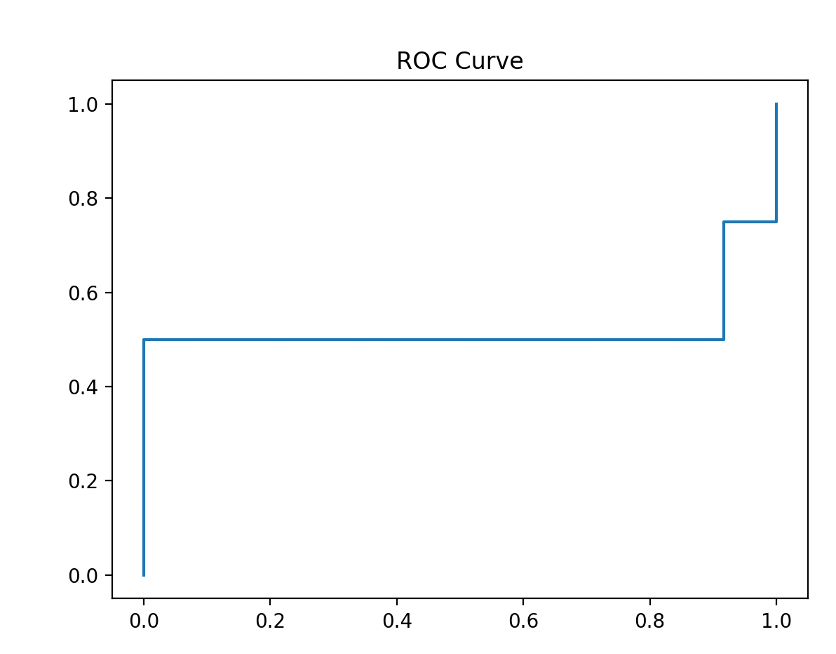

ROC-AUC = 0.52
Test accuracy = 0.43

The model achieved a test accuracy of.43 and a ROC-AUC of .52. These results are slightly lower than the internal validation performance, which suggests that the model continues to struggle generalizing beyond the training set and is still overfit.

The test ROC-AUC of .52 indicates that the model retains a very slight ability to distinguish between alive and deceased patients on new data. However, similar to the validation results, the gap between training accuracy (1.0) and test accuracy suggests that overfitting remains a limitation.

## Conclusions and Ethical Implications: 
Our analysis suggests that while MMP9 expression contributes to variation in SKCM, it is not a sole predictor of survival outcomes. This result mirrors existing research (Wu et al., 2025) ​which also supports the argument of MMP9 being a secondary influence on SKCM survival outcomes and other clinical markers. The PCA and K-means results support this by showing general clustering of patients without a clear separation driven solely by MMP9 levels. Additionally, the regression an classification supervised models both have difficulty generalizing to a test dataset to sort the data, which indicates a lack of a strong correlation in survival outcomes vs MMP9. Together, these findings reinforce the conclusion that SKCM prognosis is multifactorial, and more accurate predictions come from integrating multiple features rather than relying on a single biomarker.

These conclusions carry meaningful ethical implications. Using a single gene like MMP9 to guide clinical decisions could lead to oversimplified or inaccurate risk assessments, potentially affecting treatment choices and patient outcomes. This highlights the need for robust validation, transparency, etc when applying machine learning models in a medical context. Additionally, ensuring that models are trained on diverse and representative datasets is critical to avoid bias and ensure equitable care. Overall, these results emphasize that while ML tools are powerful for data analysis and sorting, they must be used responsibly and in conjunction with broader biological understanding.



## Limitations and Future Work: 
A key limitation of this analysis is the reliance on a relatively limited feature set and dimensionality reduction, which may obscure important gene-level signals and interactions. Additionally, focusing heavily on MMP9 restricts scope, as survival in SKCM is influenced by many genes and tumor microenvironment factors that were not fully captured (in the future we might change to focusing on a different/ several gene expression). The clustering and PCA approaches also simplify complex biological variation, and the models may be sensitive to sample size, class imbalance, or dataset-specific biases, making generalization more difficult. For more future work, expanding to larger and more diverse datasets, incorporating additional genomic and clinical features, and applying more advanced models (like deep learning approaches) would improve robustness. Further validation against independent cohorts and integration with biological pathway analysis could also help clarify the mechanisms driving survival differences and strengthen the clinical relevance of the findings.

### References

Wu, Y., Liu, X., & Hu, Z. (2025). Comprehensive investigation of matrix metalloproteinases in skin cutaneous melanoma: Diagnostic, prognostic, and therapeutic insights. BMC Cancer, 25, Article 11739484. https://doi.org/10.1186/s12885-025-11739484

## AI Usage Statement: 
Chat GPT was used to ensure our question could be analyed adequately from our data, troubleshoot PCA matching and help structure analysis code, generate k-means clustering, and suggest and implement the random forrest classifier and regression supervised learning models.

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*